In [10]:
import polars as pl
import numpy as np
import re
from datetime import date

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(100)

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [11]:
tech_path = "../data/model_staging/tech_modeling_table.parquet"
df_tech = pl.read_parquet(tech_path)
print(f"Tech table shape: {df_tech.shape}")

Tech table shape: (24048, 239)


In [12]:
# Target: car_t2_t10 = cumulative abnormal return over t+2 to t+10 (post-earnings drift)
# Features: full window t=-10 to t=+1 (no leakage since target starts at t+2)
df_tech['car_t2_t10'].describe([0.01, 0.05, 0.1, 0.25, 0.5, 0.7, 0.75, 0.9, 0.95, 0.99])

statistic,value
str,f64
"""count""",24048.0
"""null_count""",0.0
"""mean""",0.001891
"""std""",0.049086
"""min""",-0.747742
"""1%""",-0.122485
"""5%""",-0.070244
"""10%""",-0.050763
"""25%""",-0.024126


In [13]:
df_tech['target_return'].describe([0.01, 0.05, 0.1, 0.25, 0.5, 0.7, 0.75, 0.9, 0.95, 0.99])

statistic,value
str,f64
"""count""",24048.0
"""null_count""",0.0
"""mean""",0.042991
"""std""",0.045487
"""min""",-0.131541
"""1%""",-0.007509
"""5%""",0.000683
"""10%""",0.00506
"""25%""",0.014795


In [14]:
df_tech['target_return'].describe([.33,.66])

statistic,value
str,f64
"""count""",24048.0
"""null_count""",0.0
"""mean""",0.042991
"""std""",0.045487
"""min""",-0.131541
"""33%""",0.019949
"""66%""",0.046329
"""max""",1.120253


In [15]:
# filter frame where target_class =1
df_tech.filter(pl.col('target_class')==1)['target_return'].describe()

statistic,value
str,f64
"""count""",6428.0
"""null_count""",0.0
"""mean""",0.029473
"""std""",0.005759
"""min""",0.02
"""25%""",0.024529
"""50%""",0.02904
"""75%""",0.034397
"""max""",0.04


In [16]:
df_tech.filter(pl.col('target_class')==0)['target_return'].describe()

statistic,value
str,f64
"""count""",7955.0
"""null_count""",0.0
"""mean""",0.008506
"""std""",0.008128
"""min""",-0.131541
"""25%""",0.003806
"""50%""",0.009405
"""75%""",0.014645
"""max""",0.019987


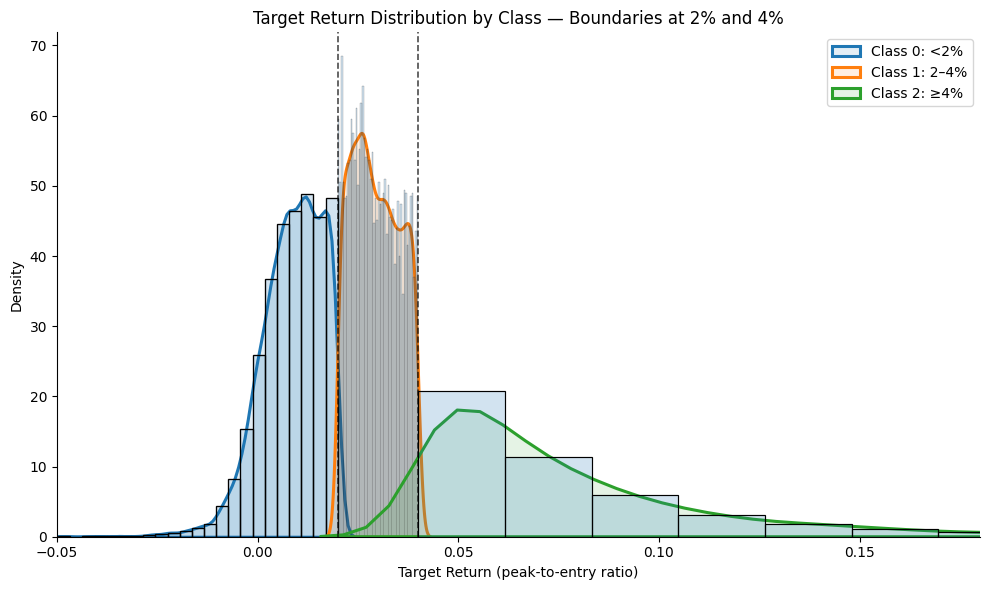

In [17]:
# Overlaid KDE + histogram of target_return by class, with class boundaries marked
classes = [0, 1, 2]
labels  = ["Class 0: <2%", "Class 1: 2–4%", "Class 2: ≥4%"]
colors  = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(10, 6))

for c, color, label in zip(classes, colors, labels):
    data = (
        df_tech.filter(pl.col("target_class") == c)
        .select("target_return")
        .to_numpy()
    )
    sns.kdeplot(
        x=data.flatten(),
        color=color,
        label=label,
        linewidth=2.2,
        ax=ax,
        fill=True,
        alpha=0.12,
    )
    sns.histplot(
        data,
        bins=50,
        color=color,
        ax=ax,
        alpha=0.20,
        stat="density",
        legend=False,
    )

# Class boundaries
for bnd in [0.02, 0.04]:
    ax.axvline(bnd, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

ax.set_xlabel("Target Return (peak-to-entry ratio)")
ax.set_ylabel("Density")
ax.set_title("Target Return Distribution by Class — Boundaries at 2% and 4%")
ax.legend()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.set_xlim(-0.05, 0.18)
plt.tight_layout()

# ═══════════════════════════════════════════════════════════════════════
# Why the 3-class split yields low accuracy
# ═══════════════════════════════════════════════════════════════════════
#
# The three classes are separated by razor-thin margins (2% and 4% peak
# return), causing severe overlap.  Target return: mean=4.3%, std=4.5%.
# Class 0 (<2%):  mean=0.85%, std=0.81%  |  Class 1 (2-4%): mean=2.95%,
# std=0.58%  |  Class 2 (>=4%): mean ~7-8%.
#
# Distribution overlap at the boundaries:
#   - 2% boundary falls within 1 std of both Class 0 and Class 1.
#   - 4% boundary: events at 3.99% vs 4.01% are indistinguishable in
#     feature space — the diff is noise, not signal.
#
# No structural break at the thresholds:
#   The target is a single unimodal distribution with heavy right tails,
#   not three natural clusters.  A return of 2.01% and 1.99% have
#   identical feature profiles; one is Class 1, the other Class 0.
#   The classifier is forced to model noise at the boundary.
#
# Tree-based models amplify boundary randomness:
#   Random Forest / XGBoost penalize a near-boundary misclassification
#   identically to a far-boundary one — inflating loss with high-noise
#   examples and diluting the signal from clearly separable tail events.
#
# Implication for modeling:
#   Regression on the continuous target_return removes arbitrary
#   thresholds and lets the model focus on ranking + magnitude directly.
#   The ablation ladder confirms this: 3-class DA hovers at 43-45% for
#   all model families, barely above the 33% random baseline.

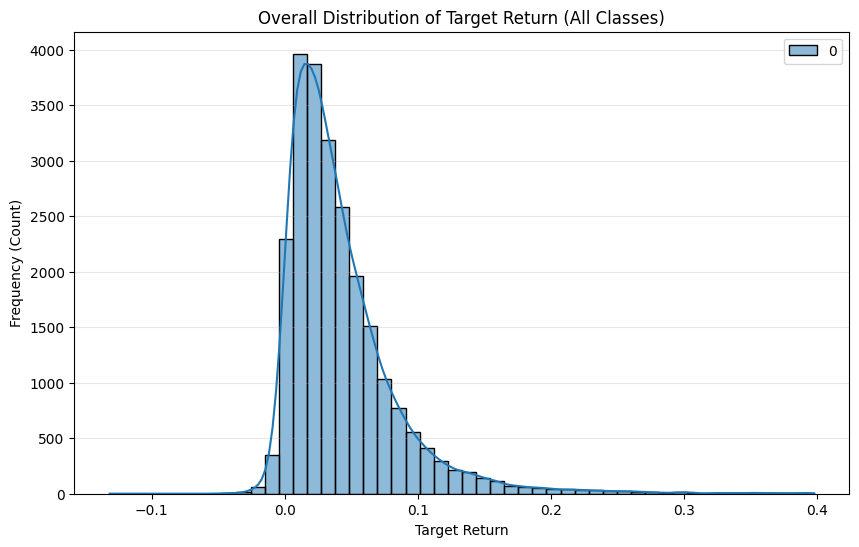

In [18]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

# 1. Extract the entire column as a NumPy array
# (No filtering needed to get all values)
# removing data return above .4 percent
df_tech = df_tech.filter(pl.col('target_return')<.4)

all_returns = df_tech.select("target_return").to_numpy()

# 2. Plot the overall histogram
plt.figure(figsize=(10, 6))
sns.histplot(
    all_returns,
    bins=50,  # Higher bin count captures finer distribution details
    kde=True,  # Adds a smooth trend line
    color="purple",  # Visual distinction from the class-specific plots
    stat="count",  # Shows the total raw frequency/row counts
)

plt.title("Overall Distribution of Target Return (All Classes)")
plt.xlabel("Target Return")
plt.ylabel("Frequency (Count)")
plt.grid(axis="y", alpha=0.3)  # Optional grid for easier reading

plt.show()


In [85]:
df_tech['car_3day'].describe([0.01, 0.05, 0.1, 0.25, 0.5, 0.7, 0.75, 0.9, 0.95, 0.99])

statistic,value
str,f64
"""count""",24048.0
"""null_count""",0.0
"""mean""",0.003473
"""std""",0.061556
"""min""",-0.538946
"""1%""",-0.160619
"""5%""",-0.09072
"""10%""",-0.064799
"""25%""",-0.029435


In [86]:
fund_path = "../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet"
df_fund = pl.read_parquet(fund_path)
df_fund = df_fund.select([
    "symbol", pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin", "gross_margin_qoq",
    "debt_to_equity", "debt_to_equity_qoq",
    "fcf_margin", "fcf_margin_qoq",
    "roe", "roe_qoq"
])

df_finbert = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_finbert = df_finbert.select([
    pl.col("symbol"), pl.col("reportedDate").alias("earnings_date"),
    "pos_prob", "neg_prob"
])

df_nz = pl.read_parquet("../data/model_staging/nz_sentiment.parquet")
df_nz = df_nz.select([
    pl.col("symbol"), pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre", "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
])

df_model = df_tech.join(df_fund, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left", suffix="_fb")
df_model = df_model.join(df_nz, on=["symbol", "earnings_date"], how="left", suffix="_nz")

df_sector_raw = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_sector = df_sector_raw.select(["symbol", "sector"]).unique()
df_sector = df_sector.with_columns(pl.col("sector").fill_null("Unknown"))
sectors = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")
df_model = df_model.join(df_sector, on="symbol", how="left")

print(f"Final shape: {df_model.shape}")

Final shape: (24048, 267)


In [87]:
exclude_cols = ["symbol", "earnings_date", "target_return", "target_class",
                "entry_price", "max_high", "min_high", "max_day", "min_day",
                "car_3day", "car_t2_t10"]
feature_cols = [c for c in df_model.columns if c not in exclude_cols]

time_cols = [c for c in feature_cols if re.match(r".+_t[+-]?\d+$", c)]
static_cols = [c for c in feature_cols if c not in time_cols]

bases = sorted(set(re.sub(r"_t[+-]?\d+$", "", c) for c in time_cols))
steps = sorted({int(re.search(r"_t([+-]?\d+)$", c).group(1)) for c in time_cols})
n_steps, n_bases, n_static = len(steps), len(bases), len(static_cols)
print(f"Time steps: {steps}  ({n_steps} steps x {n_bases} bases = {n_steps * n_bases})")
print(f"Static features: {n_static}")

Time steps: [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1]  (12 steps x 19 bases = 228)
Static features: 28


In [88]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True)
        self.fc = nn.Linear(hidden + n_static, 1)

    def forward(self, x_seq, x_stat):
        _, (hn, _) = self.lstm(x_seq)
        h = hn[-1]
        if x_stat is not None:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(-1)


class BiLSTMRegressor(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden * 2 + n_static, 1)

    def forward(self, x_seq, x_stat):
        _, (hn, _) = self.lstm(x_seq)
        h = torch.cat((hn[-2], hn[-1]), dim=1)
        if x_stat is not None:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(-1)


class CNN_LSTMRegressor(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64, kernel=3):
        super().__init__()
        self.conv = nn.Conv1d(n_bases, n_bases, kernel, padding=kernel//2)
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True)
        self.fc = nn.Linear(hidden + n_static, 1)

    def forward(self, x_seq, x_stat):
        x_seq = self.conv(x_seq.transpose(1, 2)).transpose(1, 2)
        _, (hn, _) = self.lstm(x_seq)
        h = hn[-1]
        if x_stat is not None:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(-1)

In [89]:
Train_Window = 7
Folds = [
    (date(y - Train_Window, 1, 1), date(y, 1, 1), date(y + 1, 1, 1))
    for y in range(2021, 2026)
]

# Full feature window (t=-10 to t=+1) -- no leakage since target starts at t+2
cols_for_grid = time_cols + static_cols
col_to_idx = {c: i for i, c in enumerate(cols_for_grid)}
base_to_idx = {b: i for i, b in enumerate(bases)}
step_to_idx = {s: i for i, s in enumerate(steps)}
col_grid = np.full((n_steps, n_bases), -1, dtype=int)
for c in time_cols:
    s = int(re.search(r"_t([+-]?\d+)$", c).group(1))
    b = re.sub(r"_t[+-]?\d+$", "", c)
    col_grid[step_to_idx[s], base_to_idx[b]] = col_to_idx[c]


def reshape_features(df):
    X = df.select(cols_for_grid).to_numpy().astype(np.float32)
    X = np.where(np.isinf(X), np.nan, X)
    imputer = SimpleImputer(strategy="median")
    X = imputer.fit_transform(X)
    X_time = np.zeros((X.shape[0], n_steps, n_bases), dtype=np.float32)
    for s in range(n_steps):
        for b in range(n_bases):
            idx = col_grid[s, b]
            if idx >= 0:
                X_time[:, s, b] = X[:, idx]
    X_static = X[:, [col_to_idx[c] for c in static_cols]] if n_static > 0 else None
    scaler = StandardScaler()
    X_time = scaler.fit_transform(X_time.reshape(-1, n_bases)).reshape(X_time.shape)
    if X_static is not None:
        s_scaler = StandardScaler()
        X_static = s_scaler.fit_transform(X_static)
    return X_time, X_static, imputer, scaler, (s_scaler if n_static > 0 else None)


def transform_test(df, imputer, scaler, s_scaler):
    X = df.select(cols_for_grid).to_numpy().astype(np.float32)
    X = np.where(np.isinf(X), np.nan, X)
    X = imputer.transform(X)
    X_time = np.zeros((X.shape[0], n_steps, n_bases), dtype=np.float32)
    for s in range(n_steps):
        for b in range(n_bases):
            idx = col_grid[s, b]
            if idx >= 0:
                X_time[:, s, b] = X[:, idx]
    X_time = scaler.transform(X_time.reshape(-1, n_bases)).reshape(X_time.shape)
    X_static = X[:, [col_to_idx[c] for c in static_cols]] if n_static > 0 else None
    if X_static is not None and s_scaler is not None:
        X_static = s_scaler.transform(X_static)
    return X_time, X_static


BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3

results = {}

for ModelClass, name in [(LSTMRegressor, "LSTM"), (BiLSTMRegressor, "BiLSTM"),
                          (CNN_LSTMRegressor, "CNN-LSTM")]:
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    clf = {"fold_rmse": [], "fold_mae": [], "fold_da": [], "preds": [], "true": []}

    for fold_num, (train_start, test_start, test_end) in enumerate(Folds, 1):
        train = df_model.filter(
            (pl.col("earnings_date") >= train_start) & (pl.col("earnings_date") < test_start)
        )
        test = df_model.filter(
            (pl.col("earnings_date") >= test_start) & (pl.col("earnings_date") < test_end)
        )

        X_train_t, X_train_s, imputer, scaler, s_scaler = reshape_features(train)
        X_test_t, X_test_s = transform_test(test, imputer, scaler, s_scaler)

        # Target: car_t2_t10 in percentage scale (match paper's convention)
        y_train = train["car_t2_t10"].to_numpy().astype(np.float32) * 100
        y_test = test["car_t2_t10"].to_numpy().astype(np.float32) * 100

        train_ds = TensorDataset(
            torch.tensor(X_train_t),
            torch.tensor(X_train_s) if X_train_s is not None else torch.zeros(len(X_train_t), 1),
            torch.tensor(y_train),
        )
        test_ds = TensorDataset(
            torch.tensor(X_test_t),
            torch.tensor(X_test_s) if X_test_s is not None else torch.zeros(len(X_test_t), 1),
            torch.tensor(y_test),
        )

        train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False)

        model = ModelClass(n_bases, n_static).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        loss_fn = nn.MSELoss()

        for epoch in range(EPOCHS):
            model.train()
            for x_seq, x_stat, y in train_loader:
                x_seq, x_stat, y = x_seq.to(device), x_stat.to(device), y.to(device)
                opt.zero_grad()
                loss = loss_fn(model(x_seq, x_stat if n_static > 0 else None), y)
                loss.backward()
                opt.step()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for x_seq, x_stat, y in test_loader:
                x_seq, x_stat = x_seq.to(device), x_stat.to(device)
                pred = model(x_seq, x_stat if n_static > 0 else None)
                preds.append(pred.cpu().numpy())
                trues.append(y.numpy())
        preds = np.concatenate(preds)
        trues = np.concatenate(trues)

        rmse = float(np.sqrt(mean_squared_error(trues, preds)))
        mae = float(mean_absolute_error(trues, preds))
        da = float(np.mean((np.sign(preds) == np.sign(trues))
                          | ((preds == 0) & (trues == 0))))

        clf["fold_rmse"].append(rmse)
        clf["fold_mae"].append(mae)
        clf["fold_da"].append(da)
        clf["preds"].extend(preds)
        clf["true"].extend(trues)
        print(f"  Fold {fold_num} [{test_start.year}]: RMSE={rmse:.3f}, MAE={mae:.3f}, DA={da:.3f}")

    results[name] = clf


LSTM
  Fold 1 [2021]: RMSE=5.413, MAE=3.904, DA=0.517
  Fold 2 [2022]: RMSE=7.282, MAE=5.167, DA=0.510
  Fold 3 [2023]: RMSE=4.858, MAE=3.505, DA=0.490
  Fold 4 [2024]: RMSE=5.337, MAE=3.839, DA=0.512
  Fold 5 [2025]: RMSE=6.043, MAE=4.463, DA=0.514

BiLSTM
  Fold 1 [2021]: RMSE=5.457, MAE=4.029, DA=0.490
  Fold 2 [2022]: RMSE=7.015, MAE=4.979, DA=0.520
  Fold 3 [2023]: RMSE=5.170, MAE=3.707, DA=0.483
  Fold 4 [2024]: RMSE=5.454, MAE=3.934, DA=0.503
  Fold 5 [2025]: RMSE=6.353, MAE=4.647, DA=0.496

CNN-LSTM
  Fold 1 [2021]: RMSE=5.426, MAE=3.970, DA=0.501
  Fold 2 [2022]: RMSE=6.693, MAE=4.749, DA=0.489
  Fold 3 [2023]: RMSE=4.715, MAE=3.419, DA=0.473
  Fold 4 [2024]: RMSE=5.207, MAE=3.788, DA=0.519
  Fold 5 [2025]: RMSE=6.368, MAE=4.636, DA=0.490


In [90]:
print("Table 4. Comparison with existing multimodal deep learning models.")
print(f"{'Model':<15} {'RMSE':>8} {'MAE':>8} {'DA (%)':>8}")
print("-" * 42)
for name in ["LSTM", "BiLSTM", "CNN-LSTM"]:
    r = results[name]
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    avg_rmse = np.mean(r["fold_rmse"])
    avg_mae = np.mean(r["fold_mae"])
    da_pooled = float(np.mean((np.sign(preds) == np.sign(true))
                             | ((preds == 0) & (true == 0))))
    print(f"{name:<15} {avg_rmse:>8.3f} {avg_mae:>8.3f} {da_pooled * 100:>8.2f}")

Table 4. Comparison with existing multimodal deep learning models.
Model               RMSE      MAE   DA (%)
------------------------------------------
LSTM               5.787    4.176    50.87
BiLSTM             5.890    4.259    49.85
CNN-LSTM           5.682    4.113    49.44
